In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Двухточечная квадратура Гаусса

In [3]:
from scipy.special import roots_legendre

def gauss_2(a, b):  
    roots, weights = roots_legendre(2)
    t = (b - a) / 2 * roots + (a + b) / 2
    weight = (b - a) / 2
    return t[0], t[1], weight * weights[0], weight * weights[1]

In [4]:
from numpy.testing import assert_allclose

x1, x2, w1, w2 = gauss_2(0, 1)

def f(x, n): 
    return x**n

for n in [0, 1, 2, 3]:
    assert_allclose(w1*f(x1, n=n) + w2*f(x2, n=n),
                    1./(n+1), atol=1e-14)

# 2. Вычитание интегрируемых сингулярностей

$$ \int_{0}^{1} \frac{e^x}{\sqrt{x(1-x)}} dx = \int_{0}^{0.5} \frac{e^x}{\sqrt{x(1-x)}} + \int_{0.5}^{1} \frac{e^x}{\sqrt{x(1-x)}}dx = I_1 + I_2$$

$$ I_1 = \int_{0}^{0.5} \frac{e^x - 1 - x}{\sqrt{x(1-x)}}dx + \int_{0}^{0.5} \frac{1}{\sqrt{x(1-x)}} dx + \int_{0}^{0.5} \frac{x}{\sqrt{x(1-x)}} dx$$

$$ I_2 = \int_{0.5}^{1} \frac{e^x - ex}{\sqrt{x(1-x)}}dx + \int_{0.5}^{1} \frac{ex}{\sqrt{x(1-x)}}dx$$

$$ \int \frac{1}{\sqrt{x(1-x)}}dx = \arcsin(2x - 1) + C $$

$$ \int \frac{x}{\sqrt{x(1-x)}}dx = - \sqrt{x(1-x)} + \frac{\arcsin(2x - 1)}{2} + C $$

$$ \int_{0}^{0.5} \frac{1}{\sqrt{x(1-x)}} dx = \pi / 2 $$

$$ \int_{0}^{0.5} \frac{x}{\sqrt{x(1-x)}} dx = \frac{\pi}{4} - \frac{1}{2} $$

$$ \int_{0.5}^{1} \frac{ex}{\sqrt{x(1-x)}} dx = e \left( \frac{\pi}{4} + \frac{1}{2} \right) $$

In [14]:
def f(x):
    return np.exp(x) / np.sqrt(x * (1 - x))

def f1(x):
    return (np.exp(x) - 1 - x) / np.sqrt(x * (1 - x))

def f2(x):
    return (np.exp(x) - np.e * x) / np.sqrt(x * (1 - x))

#Через трапеции численно считаем два интеграла без особенностей
def integ_f1(npts=10):
    t = np.linspace(0, 0.5, npts + 1)
    h = 0.5 / npts
    return 0.5 * h * (0 + 2 * np.sum(f1(t[1:-1])) + f1(t[-1]))

def integ_f2(npts=10):
    t = np.linspace(0.5, 1, npts + 1)
    h = 0.5 / npts
    return 0.5 * h * (f2(t[0]) + 2 * np.sum(f2(t[1:-1])) + 0)

#Выдаем приближенный ответ
def integ_f(npts = 10):
    return integ_f1(npts) + integ_f2(npts) + (np.pi / 4) - 0.5 + np.e * ((np.pi /4) + 0.5) + np.pi / 2

#Методом Рунге считаем ошибку
def err_int1(npts = 10):
    return (integ_f1(npts) - integ_f1(2 * npts)) / 3

def err_int2(npts = 10):
    return (integ_f2(npts) - integ_f2(2 * npts)) / 3

print(f"{integ_f(20000000)} - значение интеграла")
#print(f"{err_int(200)} - ошибка")
print(f"{err_int1(200)} - ошибка")
print(f"{err_int2(2000000)} - ошибка")
print(f"{integ_f1(200)} - значение интеграла")

5.508429773886107 - значение интеграла
1.678456454009177e-07 - ошибка
2.7663057030243485e-15 - ошибка
0.05053136564386079 - значение интеграла


# 3. Интеграл от осциллирующей функции (не сделано)

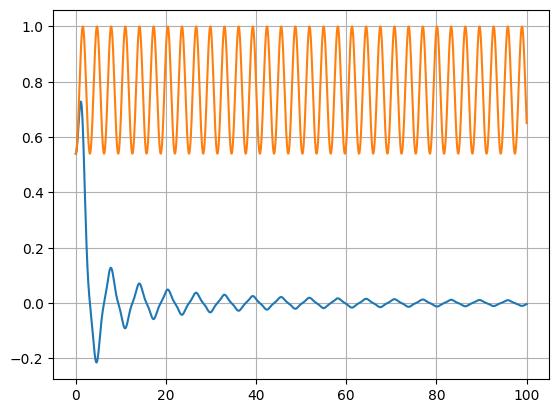

In [6]:
x = np.linspace(0.01, 100, 100000)

def strange_func(x):
    return np.sin(x) * np.cos(np.cos(x)) / x

def func(x):
    return np.cos(np.cos(x))

y_1 = strange_func(x)
y_2 = func(x)

plt.plot(x, y_1)
plt.plot(x, y_2)
plt.grid()

In [7]:
from math import sin, cos

from scipy.integrate import quad
quad(lambda x: sin(x) * cos(cos(x)) / x, 0, float('inf'))

C:\Users\kolya\AppData\Local\Temp\ipykernel_16096\778045123.py:4: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad(lambda x: sin(x) * cos(cos(x)) / x, 0, float('inf'))


(1.9653912540956733, 4.089174284042322)

# 4. Вычисление интеграла с внутренней особенностью

$$ \int_{-0.5}^{0.5} |x| ^ {-1/2} \cdot (1 - x) ^ {-1/2} $$

Рассмотрим интеграл

$$ \rho = \int_{-\delta_1}^{+\delta_2} |x| ^ {-1/2} \cdot (1 - x) ^ {-1/2} = \int_{-\delta_1}^{0} |x| ^ {-1/2} \cdot (1 - x) ^ {-1/2} +
\int_{0}^{+\delta_2} |x| ^ {-1/2} \cdot (1 - x) ^ {-1/2} = I_1 + I_2 $$

$$I_1 = \int_{-\delta_1}^{0} |x| ^ {-1/2} \cdot (1 - x) ^ {-1/2} =  \int_{-\delta_1}^{0} \frac{dx}{\sqrt{x(x - 1)}} $$

$$ \int\frac{dx}{\sqrt{x(x - 1)}} = \int\frac{dx}{\sqrt{x ^ 2 - x}} = \int\frac{dx}{\sqrt{(x - 1/2) ^ 2 - 1/4}} = [t = 2x - 1] =
\int\frac{dx}{\sqrt{t ^ 2 - 1}} = \ln|t + \sqrt{t^2 - 1}| + C = \ln\left|2x-1 + \sqrt{(2x-1)^2 - 1}\right|$$

$$I_1 = -\ln\left|-2\delta_1-1 + \sqrt{(-2\delta_1-1)^2 - 1}\right| = \ln\left|-2\delta_1-1 - \sqrt{(-2\delta_1-1)^2 - 1}\right|  $$

$$I_2 = \int_{0}^{+\delta_2} |x| ^ {-1/2} \cdot (1 - x) ^ {-1/2} = \int_{0}^{+\delta_2} \frac{dx}{\sqrt{x(1-x)}} $$

$$ \int \frac{dx}{\sqrt{x(1-x)}} = \arcsin(2x - 1) + C $$

$$I_2 = \arcsin(2\delta_2- 1) + \pi/2 $$

Находим выражение для $\rho$:

$$\rho(\delta_1, \delta_2) = \arcsin(2\delta_2- 1) + \pi/2 + \ln\left|-2\delta_1-1 - \sqrt{(-2\delta_1-1)^2 - 1}\right| $$

Требуется найти такие $\delta_1$ и $\delta_2$, что $|\rho| < \varepsilon $

Будем искать их так, что $|I_1| < \varepsilon / 2$ и $|I_2| < \varepsilon / 2$

Найдем $\delta_1$:

$$\ln\left|-2\delta_1-1 - \sqrt{(-2\delta_1-1)^2 - 1}\right| < \varepsilon / 2$$

$$\ln\left(2\delta_1+1 + \sqrt{(2\delta_1+1)^2 - 1}\right) < \varepsilon / 2$$

$$\cosh^{-1}(2\delta_1 + 1) < \varepsilon / 2 $$

$$\delta_1 < \frac{\cosh(\varepsilon/2) - 1}{2} = \sinh^2(\varepsilon/4)  \text{,}$$

то неравенство будет выполняться

Найдем $\delta_2$:

$$|\arcsin(2\delta_2- 1) + \pi/2| < \varepsilon/2$$

$$\arcsin(2\delta_2- 1) + \pi/2 < \varepsilon/2$$

$$2\delta_2 - 1 < \sin{(\varepsilon/2 - \pi/2)}$$

$$ \delta_2 < \frac{\sin{(\varepsilon/2 - \pi/2)} + 1}{2} $$

$$ \delta_2 < \frac{1 - \cos{(\varepsilon/2)}}{2} = \sin^2{(\varepsilon/4)} $$

Итоговый ответ:

$$\delta_1 = \sinh^2(\varepsilon/4)$$

$$\delta_2 = \sin^2{(\varepsilon/4)}$$

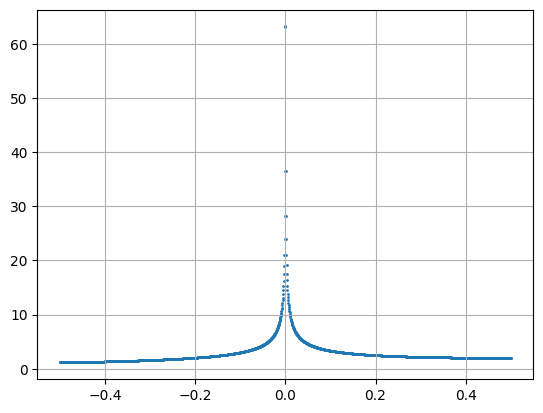

In [8]:
def f_feature(x):
    return np.abs(x) ** (-1/2) * (1 - x) ** (-1/2)

x = np.linspace(-0.5, 0.5, 2000)
y = f_feature(x)

plt.scatter(x, y, s = 1)
plt.grid()

# 5. Интеграл от быстроосциллирующей функции

$$\large \int_0^{\pi}e^{-x} \sin{kx} dx $$

0.09473637293513214 0.09473129522140869
-1.3890707321349088e-15 0.009566904126949584
2.8262681584079806e-14 0.0009567851249511028
3.8354538310472945e-13 9.56786072168367e-05


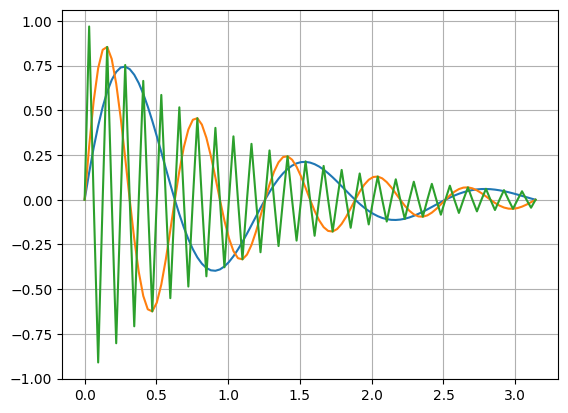

In [9]:
def f_ocs(x, k = 1000):
    return np.exp(-x) * np.sin(k * x)

amount_t = 101

t = np.linspace(0, np.pi, amount_t)
f = f_ocs(t)

#Считаем приближенно методом Симпсона
def simpson(f, h):
    assert (len(f)-1) % 2 == 0
    return h/3. * (f[0] + 4 * sum(f[1:-1:2]) + \
                   2 * sum(f[2:-2:2]) + f[-1])

#Аналиттическое значение
def true_int(k):
    return (k / (1 + k ** 2)) - (np.exp(-np.pi) * (k * np.cos(k * np.pi) + np.sin(k * np.pi))) / (1 + k ** 2)

simpson(f, np.pi / (len(f) - 1)), true_int(1000)

for k in [10, 100, 1000, 10000]:
    f = f_ocs(t, k)
    print(simpson(f, np.pi / (len(f) - 1)), true_int(k))

for k in [5, 10, 50]:
    plt.plot(t, f_ocs(t, k))

plt.grid()

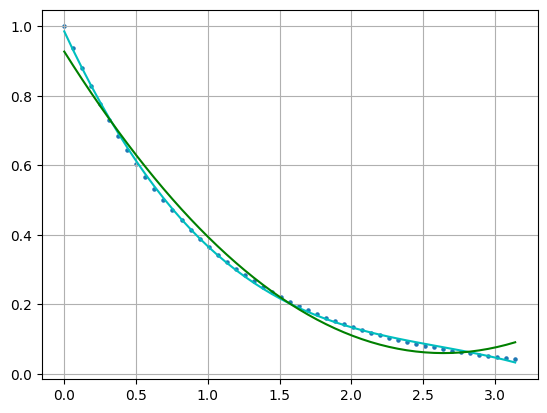

In [10]:
import sympy

amount_x1 = 51

x1 = np.linspace(0, np.pi, amount_x1)
y1 = np.exp(-x1)

coeffs_3 = np.polyfit(x1, y1, 3)
y_pred_3 = np.polyval(coeffs_3, x1)

x = sympy.symbols('x', real=True, positive=True)
k = sympy.symbols('k', real=True, positive=True, integer = True)

P_3 = coeffs_3[3] + coeffs_3[2] * x + coeffs_3[1] * x ** 2 + coeffs_3[0] * x ** 3

J_sym_3 = sympy.integrate(P_3 * sympy.sin(k*x), (x, 0, sympy.pi))
J_func_3 = sympy.lambdify(k, J_sym_3, 'numpy')

coeffs_2 = np.polyfit(x1, y1, 2)
y_pred_2 = np.polyval(coeffs_2, x1)

P_2 = coeffs_2[2] + coeffs_2[1] * x + coeffs_2[0] * x ** 2

J_sym_2 = sympy.integrate(P_2 * sympy.sin(k*x), (x, 0, sympy.pi))
J_func_2 = sympy.lambdify(k, J_sym_2, 'numpy')

plt.scatter(x1, y1, s = 5)
plt.plot(x1, y_pred_3, c = 'c')
plt.plot(x1, y_pred_2, c = 'g')
plt.grid()

In [11]:
Simpson = []
Simpson_err = []
P2 = []
P2_err = []
P3 = []
P3_err = []
Answer = []
Value_k = []

x = sympy.symbols('x', real=True, positive=True)
k = sympy.symbols('k', real=True, positive=True, integer = True)

for k in [1, 10, 100, 1000, 10000, 20000, 40000]:
    f_ocs_ = f_ocs(t, k)
    Value_k.append(k)
    P3.append(J_func_3(k))
    P2.append(J_func_2(k))
    P2_err.append(abs((J_func_2(k) - true_int(k)) / true_int(k)))
    P3_err.append(abs((J_func_3(k) - true_int(k)) / true_int(k)))
    Simpson.append(simpson(f_ocs_, np.pi / (len(f_ocs_) - 1)))
    Simpson_err.append(abs((simpson(f_ocs_, np.pi / (len(f_ocs_) - 1)) - true_int(k)) / true_int(k)))
    Answer.append(true_int(k))

In [12]:
import pandas as pd
df = pd.DataFrame(
    {
        "Value_k": Value_k,
        "True answer": Answer,
        "Simpson": Simpson,
        "Polynom (deg = 2)": P2,
        "Polynom (deg = 3)": P3,
        "P2_err": P2_err,
        "P3_err": P3_err,
        "Simpson_err": Simpson_err
    }
)

df

,Value_k,True answer,Simpson,Polynom (deg = 2),Polynom (deg = 3),P2_err,P3_err,Simpson_err
0,1,0.521607,5.216069e-01,0.521312,0.521312,0.000566,0.000566,2.165155e-08
1,10,0.094731,9.473637e-02,0.083666,0.094545,0.116811,0.001971,5.360123e-05
2,100,0.009567,-1.389071e-15,0.008367,0.009529,0.125468,0.003976,1.000000e+00
3,1000,0.000957,2.826268e-14,0.000837,0.000953,0.125555,0.003997,1.000000e+00
4,10000,0.000096,3.835454e-13,0.000084,0.000095,0.125556,0.003997,1.000000e+00
5,20000,0.000048,7.670908e-13,0.000042,0.000048,0.125556,0.003997,1.000000e+00
6,40000,0.000024,1.534182e-12,0.000021,0.000024,0.125556,0.003997,9.999999e-01


# 6. Интегрирование с помощью ортогональных полиномов

$$ I = \int_0^{2\pi} \frac{\cos{(x)dx}}{\sqrt{4\pi^2 - x^2}} = \int_0^{1} \frac{\cos{(2\pi t)dt}}{\sqrt{1 - t^2}} = 
\frac{1}{2}\int_{-1}^{1} \frac{\cos{(2\pi t)dt}}{\sqrt{1 - t^2}} \text{, } x = 2\pi t$$

$$ 2I = \int_{-1}^{1} \frac{\cos{(2\pi t) - 1}}{\sqrt{1 - t^2}} + \int_{-1}^{1} \frac{{1}}{\sqrt{1 - t^2}} dt = 
 \int_{-1}^{1} \frac{\cos{(2\pi t) - 1}}{\sqrt{1 - t^2}} + \pi$$

In [15]:
import sympy as sp

x = sp.symbols('x', real=True, positive=True)

f_hard = sp.cos(2 * sp.pi * x) / sp.sqrt(1 - x ** 2)

I = sp.integrate(f_hard, (x, 0, 1))

print(f'{float(I)} - ответ')

0.34601015881226443 - ответ


In [31]:
from scipy.special import roots_chebyt
def chebyt_n(n):  
    roots, weights = roots_chebyt(n)
    return np.array(roots), np.array(weights)

def f(x):
    return np.cos(2 * np.pi * x) - 1


J_fw = f(chebyt_n(10)[0]) @ chebyt_n(10)[1] + np.pi
J_fw / 2

0.3460101517706766